In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from joblib import dump, load

from xai_aux import CFCalculations

pd.set_option("display.max_columns", 99)

In [2]:
def get_distance(A,B, continuous_columns, categorical_columns, l_norm=2, n_features=1):
    
    combined = np.vstack((A, B))
    
    stds = np.std(combined[:, categorical_columns], axis=0)
    epsilon = 1e-8
    adjusted_stds = np.where(stds == 0, epsilon, stds) 

    weights_categorical = 1.48 / adjusted_stds
    mads = np.median(np.abs(combined[:, continuous_columns] - 
                            np.median(combined[:, continuous_columns], axis=0)), axis=0)
    adjusted_mads = np.where(mads == 0, epsilon, mads) 
    weights_continuous = 1 / adjusted_mads

    # Combine weights
    weights = np.zeros(combined.shape[1])
    weights[categorical_columns] = weights_categorical
    weights[continuous_columns] = weights_continuous

    # Compute weighted L2 distances for same-index pairs
    differences = A - B  # Element-wise differences
    weighted_differences = differences * weights  # Apply weights element-wise
    l_distances = np.linalg.norm(weighted_differences, axis=1, ord=l_norm)/n_features
    return l_distances

In [3]:
l_order = 1
completeness_limit = 0.88
cm = ['TP','FP','FN','TN']

colours = {('lr', 'skl'): 'deepskyblue', 
           ('lr', 'blr_marg'): 'blue', 
           ('lr', 'blr_mean'): 'lightblue',
           ('lr', 'nice'): 'magenta',
           ('lr', 'dice'): 'hotpink', 
           ('lr', 'RL'): 'lavender',
           ('rf', 'nice'): 'darkorange',
           ('rf', 'dice'): 'orange',
           ('rf', 'RL'): 'palegoldenrod',
           ('tf', 'nice'): 'darkgreen', 
           ('tf', 'dice'): 'lightgreen'
           }

In [4]:
def load_dataset(dataset_name, variant="standard",n_datasets=11):
    """
    Load only the requested dataset variant.
    
    Parameters:
        dataset_name (str): Name of the dataset (e.g., "mock_data_3", "gsc", etc.).
        variant (str): One of ["standard", "noniid_test", "ommited_var_test"].
    
    Returns:
        dict: Loaded dataset components.
    """
    base_path = f"/Users/leo/xai-cfs/data/{dataset_name}"
    print(base_path)
    
    # Validate variant
    if variant not in ["standard", "noniid_test", "ommited_var_test"]:
        raise ValueError(f"Unknown variant: {variant}")

    # Special handling for mock datasets
    if dataset_name.startswith("mock_data"):
        mock_num = dataset_name[-1]
        
        # Only mock_data_3 supports extra variants
        if variant in ["noniid_test", "ommited_var_test"] and mock_num != "3":
            raise ValueError(f"{variant} is only available for mock_data_3")

    # Define paths based on the variant
    if variant == "standard":
        dataset_path = f"{base_path}_cf_results_dict.pkl"
        model_results_path = f"{base_path}_model_results.pkl"
        cfs_good_indices_path = f"{base_path}_cfs_good_indices.pkl"
        cf_calc_paths = [f"{base_path}_{i}.pkl" for i in range(n_datasets)]
    else:
        dataset_path = f"{base_path}_{variant}_cf_results_dict.pkl"
        model_results_path = f"{base_path}_{variant}_model_results.pkl"
        cfs_good_indices_path = f"{base_path}_{variant}_cfs_good_indices.pkl"
        cf_calc_paths = [f"{base_path}_{variant}{i}.pkl" for i in range(n_datasets)]

    # Load only the requested dataset
    return {
        "cf_results_dict": load(dataset_path),
        "cf_calc": [load(path) for path in cf_calc_paths],
        "model_results_dict": load(model_results_path),
        "cfs_good_indices": load(cfs_good_indices_path),
    }

In [102]:
# Choose dataset dynamically
dataset = "adult_income" # options: "adult_income" "german_credit" "gsc" "mock_data3"
variant = "standard"  # "noniid_test" #"standard" "ommited_var_test"
data = load_dataset(dataset, variant=variant,n_datasets=9) # "ommited_var_test" "noniid_test" "standard"

# Extract variables
cf_results_dict = data["cf_results_dict"]
cf_calc = data["cf_calc"]
model_results_dict = data["model_results_dict"]
cfs_good_indices = data["cfs_good_indices"]

/Users/leo/xai-cfs/data/adult_income


In [103]:
noises_list = list(cf_results_dict.keys())[1:]
cf_methods = list(cf_results_dict[noises_list[0]].keys())
n_features = np.array(cf_results_dict['noise_0'][('lr','nice')]).shape[1]
numerical_columns = [int(i) for i in cf_calc[0].num_cols_tf]
categorical_columns = [int(i) for i in cf_calc[0].cat_cols_tf]

IndexError: list index out of range

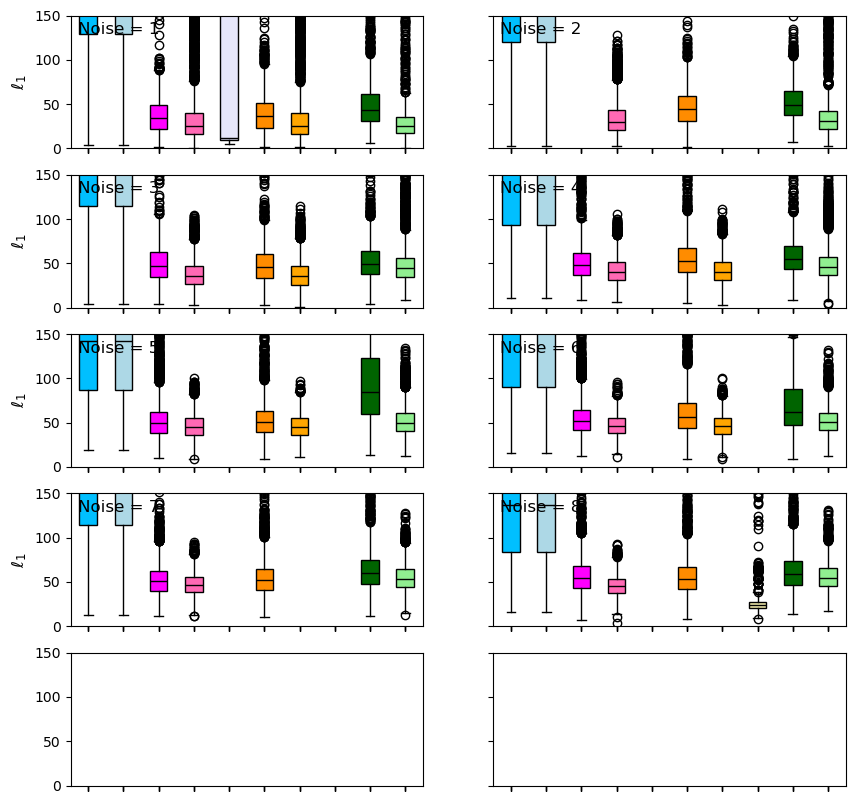

In [104]:
n_rows, n_cols = 5, 2  # Define explicitly to be adaptable
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    d2 = []
    labels = []
    colour_list = []
    
    # Define the total number of labels expected (assuming 11 methods)
    expected_labels = [k[0] + ' ' + k[1] for k in cf_methods]  # All possible labels
    expected_d2 = {label: [] for label in expected_labels}  # Dictionary to store distances

    for k in cf_methods:
        colour_list.append(colours[k])
        A = cf_results_dict[noises_list[i]][k]
        B = cf_results_dict['noise_0'][k]

        if k[1] in {'nice', 'dice', 'RL'} and k[0] != 'tf':
            A = cf_calc[i].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
            B = cf_calc[i].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)

        good_indices = cfs_good_indices[noises_list[i]][k]
        
        if sum(good_indices) / len(good_indices) > completeness_limit:
            expected_d2[k[0] + ' ' + k[1]] = get_distance(
                A[good_indices], B[good_indices], numerical_columns, categorical_columns, 
                l_norm=l_order,)

    # Ensure that all expected labels appear, even if they have no data points
    d2 = list(expected_d2.values())  # Boxplot data (some lists will be empty)
    labels = list(expected_d2.keys())  # Ensure all labels appear

    # Apply x-labels only for the last row
    if i // n_cols == n_rows - 1:
        bplot = ax.boxplot(d2, tick_labels=labels, widths=0.5, patch_artist=True)
    else:
        bplot = ax.boxplot(d2, tick_labels=['' for _ in labels], widths=0.5, patch_artist=True)

    ax.set_ylim([0, 150])

    for patch, color in zip(bplot['boxes'], colour_list):
        patch.set_facecolor(color)
    for median in bplot['medians']:
        median.set_color('black')

    ax.text(0.02, 0.95, 'Noise = ' + noises_list[i][6:9], fontsize=12,
            verticalalignment='top', horizontalalignment='left',
            transform=ax.transAxes)
    
    # Set y-labels for leftmost column
    if i % n_cols == 0:
        ax.set_ylabel(r'$\ell_1$', fontsize=12, fontweight='bold')

    ax.tick_params(axis='x', labelrotation=45)

fig.subplots_adjust(wspace=0, hspace=0)  # Set space between subplots to zero
fig.savefig("plots/"+dataset+"_"+variant+".pdf", format="pdf", bbox_inches="tight")


In [ ]:
def model_dict_to_df(model_dict):
    df = pd.DataFrame.from_dict(model_dict, orient='index', columns=['value'])
    df.index = pd.MultiIndex.from_tuples(df.index, names=['model', 'metric'])
    df = df.unstack(level=1)
    df.columns = df.columns.droplevel(1)
    df = df.reset_index()
    df.columns = ['model','accuracy', 'precision']
    return df

In [ ]:
methods2 = ['R19', 'BR19 (Mean)', 'BR19 (Marg)', 'DiCE', 'NICE', 'RL']
d2 = {'R19':[('lr', 'skl')], 
      'BR19 (Marg)':[('lr', 'blr_marg')], 
      'BR19 (Mean)':[('lr', 'blr_mean')], 
      'DiCE': [('lr', 'dice'), ('rf', 'dice'),('tf', 'dice')],
      'NICE': [('lr', 'nice'), ('rf', 'nice'),('tf', 'dice')],
      'RL': [('lr', 'RL'),('rf', 'RL')]}

In [ ]:
dfs = []
for i in model_results_dict:
    df_t = model_dict_to_df(model_results_dict[i])
    df_t.insert(0,'Noise Level',i)
    df_t.insert(0,'Variant',variant)
    df_t.insert(0,'Dataset',dataset)
    dfs.append(df_t)
df = pd.concat(dfs).reset_index(drop=True) # dfs concatanation here

for j in [i+' Compl' for i in methods2]:
    df[j] = np.nan
for j in [i+' L1' for i in methods2]:
    df[j] = np.nan
for j in [i+' L2' for i in methods2]:
    df[j] = np.nan
    
for noise in list(cf_results_dict.keys()):
    ii = int(noise.split("_")[-1])
    for k in methods2:
        for m in d2[k]:
            try:
                compl = sum(cfs_good_indices[noise][m])/len(cfs_good_indices[noise][m])
                if m[1]=='skl':
                    model_sel = 'lr'
                elif m[1]=='blr_mean':
                    model_sel = 'blr'
                elif m[1]=='blr_marg':
                    model_sel = 'blr'
                else:
                    model_sel = m[0]
                sel = (df['Noise Level']==noise)&(df['model']==model_sel)
                df.loc[sel, k+' Compl'] = compl
                A = cf_results_dict[noise][m]
                B = cf_results_dict['noise_0'][m]
                if m[1]=='nice' or m[1]=='dice' or m[1]=='RL':
                    if m[0]!='tf':
                        A = cf_calc[ii-1].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
                        B = cf_calc[0].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)
                good_indices = cfs_good_indices[noise][m]
                df.loc[sel,k+' L1'] = get_distance(
                    A[good_indices], B[good_indices], numerical_columns, categorical_columns, 
                    l_norm=1).mean()
                df.loc[sel,k+' L2'] = get_distance(
                    A[good_indices], B[good_indices], numerical_columns, categorical_columns, 
                    l_norm=2).mean()
            except KeyError:
                pass
df.to_csv('data/output_'+dataset+"_"+variant+".csv", index=False)

/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/var/folders/v3/8m8d5hfj2zdby10rq6l2ttyw0000gn/T/ipykernel_28607/1311693493.py:43: RuntimeWarning: Mean of empty slice.
  l_norm=1).mean()
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <=

IndexError: list index out of range

In [ ]:
def add_text_in_subplot(ax_in,text_in):
    xlim = ax_in.get_xlim()
    ylim = ax_in.get_ylim()
    x_text = xlim[0] + 0.02 * (xlim[1] - xlim[0])  # 2% from left
    y_text = ylim[1] - 0.05 * (ylim[1] - ylim[0])  # 5% from top
    ax_in.text(x_text, y_text, text_in, fontsize=10, verticalalignment='top', horizontalalignment='left')
    return

In [112]:
if dataset == "adult_income":
    num_feat = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
    cat_feat = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'native-country']
    cols = cat_feat + num_feat
    sel = cf_calc[0].cm_data['lr']=='FN'
    row_in = 70 #58 #56 #55 #2
    ml_cf = list(cf_results_dict['noise_1'].keys())[3]
    print(ml_cf)
    s0 = pd.Series(cf_calc[0].df_test[sel].iloc[row_in].values, index=cols)
    s1 = pd.Series(np.array(cf_results_dict[noises_list[0]][ml_cf])[sel][row_in], index=cols)
    s2 = pd.Series(np.array(cf_results_dict[noises_list[1]][ml_cf])[sel][row_in], index=cols)
    s3 = pd.Series(np.array(cf_results_dict[noises_list[2]][ml_cf])[sel][row_in], index=cols)
    s4 = pd.Series(np.array(cf_results_dict[noises_list[3]][ml_cf])[sel][row_in], index=cols)
    df_paper = pd.concat([s0,s1,s2,s3,s4],axis=1)
    df_paper.columns = ['Original', 'Noise 0 CF', 'Noise 1 CF', 'Noise 2 CF', 'Noise 3 CF']


    
elif dataset == "gsc":
    num_feat = [str(i) for i in range(10)]
    cols = num_feat
    row_in = 6
    sel = cf_calc[0].cm_data['lr']=='FP'
    ml_cf = list(cf_results_dict['noise_1'].keys())[1]

    print(ml_cf)
    s0 = pd.Series(cf_calc[0].df_test[sel].iloc[row_in].values, index=cols)
    s1 = pd.Series(np.array(cf_results_dict[noises_list[0]][ml_cf])[sel][row_in], index=cols)
    s2 = pd.Series(np.array(cf_results_dict[noises_list[1]][ml_cf])[sel][row_in], index=cols)
    s3 = pd.Series(np.array(cf_results_dict[noises_list[2]][ml_cf])[sel][row_in], index=cols)
    s4 = pd.Series(np.array(cf_results_dict[noises_list[3]][ml_cf])[sel][row_in], index=cols)
    df_paper = pd.concat([s0,s1,s2,s3,s4],axis=1).iloc[[0,3]]
    df_paper.index = ['credit card balance over credit limit', 'expenses over income']
    df_paper.columns = ['Original', 'Noise 0 CF', 'Noise 1 CF', 'Noise 2 CF', 'Noise 3 CF']

    # Plot with arrows
    plt.figure(figsize=(8, 6))
    for i in range(len(df) - 1):
        x, y = df_paper.T.iloc[i]
        dx, dy = df_paper.T.iloc[i + 1] - df_paper.T.iloc[i]
        plt.arrow(x, y, dx, dy, head_width=0.02, length_includes_head=True, color='blue')

    # Plot points
    plt.scatter(df_paper.T['credit card balance over credit limit'], df_paper.T['expenses over income'], c='red')
    for label, (x, y) in df_paper.T.iterrows():
        plt.text(x + 0.01, y + 0.01, label)

    plt.xlabel("Credit Card Balance / Credit Limit")
    plt.ylabel("Expenses / Income")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("plots/"+dataset+"_"+variant+"_CF_move.pdf", format="pdf", bbox_inches="tight")
else:
    pass

# print(ml_cf)
# for row_in in range(100):
#     s0 = pd.Series(cf_calc[0].df_test[sel].iloc[row_in].values, index=cols)
#     s1 = pd.Series(np.array(cf_results_dict[noises_list[0]][ml_cf])[sel][row_in], index=cols)
#     s2 = pd.Series(np.array(cf_results_dict[noises_list[1]][ml_cf])[sel][row_in], index=cols)
#     s3 = pd.Series(np.array(cf_results_dict[noises_list[2]][ml_cf])[sel][row_in], index=cols)
#     s4 = pd.Series(np.array(cf_results_dict[noises_list[3]][ml_cf])[sel][row_in], index=cols)
#     df_paper = pd.concat([s0,s1,s2,s3,s4],axis=1).iloc[[0,3]]
#     df_paper.columns = ['Original', 'Noise 0 CF', 'Noise 1 CF', 'Noise 2 CF', 'Noise 3 CF']
#     if (df_paper>=0).all(axis=None):
#         print(row_in, df_paper)
#         break

('lr', 'dice')


In [113]:
df_paper

,Original,Noise 0 CF,Noise 1 CF,Noise 2 CF,Noise 3 CF
workclass,Local-gov,State-gov,Private,Private,Private
education,HS-grad,HS-grad,Bachelors,HS-grad,HS-grad
marital-status,Married-civ-spouse,Never-married,Divorced,Never-married,Married-civ-spouse
occupation,Protective-serv,Protective-serv,Prof-specialty,Adm-clerical,Protective-serv
relationship,Husband,Husband,Husband,Husband,Own-child
native-country,usa,usa,usa,usa,usa
age,28.0,24.976069,24.703968,60.626373,19.365387
education-num,9.0,8.205422,7.985175,7.319357,10.151027
capital-gain,0.0,40640.408215,61569.11172,82139.63338,81960.195373
capital-loss,0.0,136.931572,2.452189,386.029723,1406.306789


In [114]:
latex_str = df_paper.to_latex(index=True, header=True, escape=True, float_format="%.0f")
print(latex_str)

\begin{tabular}{llllll}
\toprule
 & Original & Noise 0 CF & Noise 1 CF & Noise 2 CF & Noise 3 CF \\
\midrule
workclass & Local-gov & State-gov & Private & Private & Private \\
education & HS-grad & HS-grad & Bachelors & HS-grad & HS-grad \\
marital-status & Married-civ-spouse & Never-married & Divorced & Never-married & Married-civ-spouse \\
occupation & Protective-serv & Protective-serv & Prof-specialty & Adm-clerical & Protective-serv \\
relationship & Husband & Husband & Husband & Husband & Own-child \\
native-country & usa & usa & usa & usa & usa \\
age & 28 & 25 & 25 & 61 & 19 \\
education-num & 9 & 8 & 8 & 7 & 10 \\
capital-gain & 0 & 40640 & 61569 & 82140 & 81960 \\
capital-loss & 0 & 137 & 2 & 386 & 1406 \\
hours-per-week & 40 & 44 & 39 & 51 & 47 \\
\bottomrule
\end{tabular}



/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/co

('rf', 'nice')
[165.91222554 184.07432439 308.07243319 151.53409212 236.99367475
 250.52411658 209.04379298 231.55324342 246.90765565 302.22234469]


/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


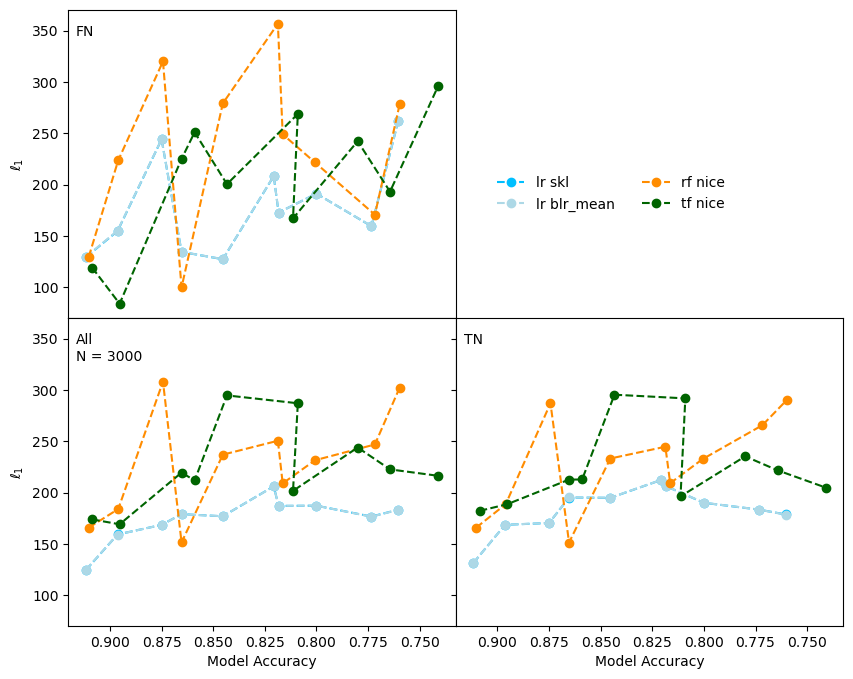

In [ ]:
#fig, axes = plt.subplots(2, 2, figsize=(10, 8), gridspec_kw={'height_ratios': [1, 1], 'width_ratios': [1, 1]})
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
(ax_top, _), (ax_bottom_left, ax_bottom_right) = axes

# Remove the top-right plot
fig.delaxes(axes[0, 1])  # This removes the top-right subplot

# fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)
# ax_top, (ax_bottom_left, ax_bottom_right) = axes[0], axes[1].subplots(1, 2, sharex=True, sharey=True)

for i, kk in enumerate(cf_methods):
    x_acc = []
    d2 = []
    compl = {}

    for k in cf_results_dict:
        if k == 'noise_0': continue
        ii = int(k.split("_")[-1])
        A = cf_results_dict[k][kk]
        B = cf_results_dict['noise_0'][kk]

        if kk[1] in ['nice', 'dice', 'RL'] and kk[0] != 'tf':
            A = cf_calc[ii-1].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
            B = cf_calc[0].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)

        good_indices = cfs_good_indices[k][kk]
        #print("Dataset size: ", len(good_indices))

        # Default: Original Selection
        d_temp = get_distance(A[good_indices], B[good_indices], numerical_columns, categorical_columns, l_norm=l_order)
        if len(d_temp) > 0:
            d2.append(d_temp)
            compl[(kk, k)] = (sum(good_indices) / len(good_indices))
            x_acc.append(model_results_dict[k][(kk[0], 'accuracy')])

    d2 = np.array([np.array([np.mean(i), np.percentile(i, 25), np.percentile(i, 75)]) for i in d2])

    if len(d2) == 0:
        continue

    # -----------------------------
    # Top Plot (False Negatives - FN) with good_indices
    # -----------------------------
    x_acc_fn = []
    d2_fn = []
    for k in cf_results_dict:
        if k == 'noise_0': continue
        ii = int(k.split("_")[-1])
        A = cf_results_dict[k][kk]
        B = cf_results_dict['noise_0'][kk]

        if kk[1] in ['nice', 'dice', 'RL'] and kk[0] != 'tf':
            A = cf_calc[ii-1].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
            B = cf_calc[0].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)

        fn_indices = (cf_calc[ii-1].cm_data['blr'] == 'FN') #& good_indices
        d_temp_fn = get_distance(A[fn_indices], B[fn_indices], numerical_columns, categorical_columns, l_norm=l_order)

        if len(d_temp_fn) > 0:
            d2_fn.append(d_temp_fn)
            x_acc_fn.append(model_results_dict[k][(kk[0], 'accuracy')])

    d2_fn = np.array([np.array([np.mean(i), np.percentile(i, 25), np.percentile(i, 75)]) for i in d2_fn])

    if len(d2_fn) > 0:
        if any(value < completeness_limit for value in compl.values()):
            pass
        else:
            ax_top.plot(x_acc_fn, d2_fn[:, 0], color=colours[kk], label=kk[0] + ' ' + kk[1], alpha=1, linestyle='--', marker='o')

    # -----------------------------
    # Bottom-Right Plot (True Negatives - TN) with good_indices
    # -----------------------------
    x_acc_tn = []
    d2_tn = []
    for k in cf_results_dict:
        if k == 'noise_0': continue
        ii = int(k.split("_")[-1])
        A = cf_results_dict[k][kk]
        B = cf_results_dict['noise_0'][kk]

        if kk[1] in ['nice', 'dice', 'RL'] and kk[0] != 'tf':
            A = cf_calc[ii-1].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
            B = cf_calc[0].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)

        tn_indices = (cf_calc[ii-1].cm_data['blr'] == 'TN') #& good_indices
        d_temp_tn = get_distance(A[tn_indices], B[tn_indices], numerical_columns, categorical_columns, l_norm=l_order)

        if len(d_temp_tn) > 0:
            d2_tn.append(d_temp_tn)
            x_acc_tn.append(model_results_dict[k][(kk[0], 'accuracy')])

    d2_tn = np.array([np.array([np.mean(i), np.percentile(i, 25), np.percentile(i, 75)]) for i in d2_tn])

    if len(d2_tn) > 0:
        if any(value < completeness_limit for value in compl.values()):
            pass
        else:
            ax_bottom_right.plot(x_acc_tn, d2_tn[:, 0], color=colours[kk], label=kk[0] + ' ' + kk[1], alpha=1, linestyle='--', marker='o')

    # -----------------------------
    # Standard Plot (Bottom-Left)
    # -----------------------------
    if any(value < completeness_limit for value in compl.values()):
        pass
    else:
        if kk[0]=='rf':
            print(kk)
            print(d2[:,0])
        ax_bottom_left.plot(x_acc, d2[:, 0], color=colours[kk], label=kk[0] + ' ' + kk[1], alpha=1, linestyle='--', marker='o')

# Formatting plots
for ax in [ax_top, ax_bottom_left, ax_bottom_right]:
    ax.set_xlabel('Model Accuracy')
    ax.invert_xaxis()
    #ax.set_ylim([20,100])

add_text_in_subplot(ax_bottom_left,'All\nN = ' + str(len(good_indices)))
add_text_in_subplot(ax_bottom_right,'TN')
add_text_in_subplot(ax_top,'FN')
#add_text_in_subplot(ax_bottom_right,'TN\nN = ' + str(tn_indices.sum()))
#add_text_in_subplot(ax_top,'FN\nN = ' + str(fn_indices.sum()))

ax_bottom_right.legend(loc="upper center", bbox_to_anchor=(0.4, 1.5), ncol=2, frameon=False)

ax_top.set_ylabel(r'$\ell_1$')
ax_bottom_left.set_ylabel(r'$\ell_1$ ')

fig.subplots_adjust(wspace=0, hspace=0)  # Set space between subplots to zero
fig.savefig("plots/"+dataset+"_"+variant+"_l1_mean.pdf", format="pdf", bbox_inches="tight")

lr [0.931, 0.9116666666666666, 0.8963333333333333, 0.875, 0.8653333333333333, 0.8453333333333334, 0.8206666666666667, 0.8183333333333334, 0.8, 0.7733333333333333, 0.7603333333333333]
blr [0.931, 0.9116666666666666, 0.8963333333333333, 0.875, 0.8653333333333333, 0.8453333333333334, 0.8206666666666667, 0.8183333333333334, 0.8, 0.7733333333333333, 0.7603333333333333]
rf [0.935, 0.9103333333333333, 0.896, 0.8743333333333333, 0.8653333333333333, 0.8453333333333334, 0.8186666666666667, 0.8163333333333334, 0.8006666666666666, 0.7716666666666666, 0.7596666666666667]
tf [0.9343333333333333, 0.9086666666666666, 0.8953333333333333, 0.8653333333333333, 0.859, 0.8433333333333334, 0.809, 0.8113333333333334, 0.78, 0.7643333333333333, 0.741]


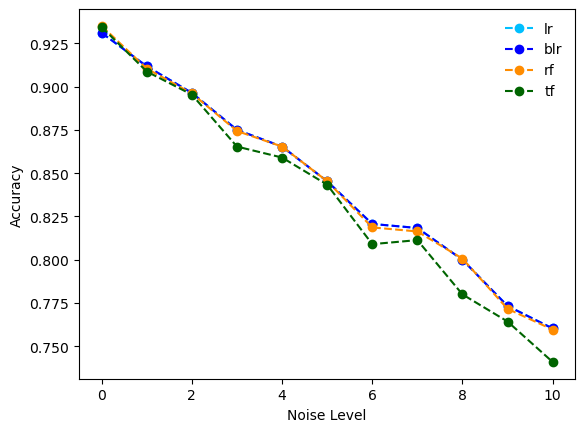

In [ ]:
colours2 = {'lr': 'deepskyblue', 'blr': 'blue', 'rf':'darkorange', 'tf':'darkgreen'}
mm = []
for i, kk in enumerate(cf_methods):
    x_acc = []
    x_prec = []
    if kk[1]=='blr_mean':
        m_in = 'blr'
    else:
        m_in = kk[0]
    if m_in in mm: continue
    mm.append(m_in)
    for k in cf_results_dict:
        x_acc.append(model_results_dict[k][(kk[0], 'accuracy')])
        x_prec.append(model_results_dict[k][(kk[0], 'precision')])
    print(m_in, x_acc)
    plt.plot(x_acc, label=m_in, color=colours2[m_in], linestyle='--', marker='o')
    #plt.plot(x_prec, label=m_in, color=colours2[m_in], linestyle='-.', marker='s')
plt.legend(frameon=False)
plt.xlabel('Noise Level')
plt.ylabel('Accuracy')
plt.savefig("plots/"+dataset+"_"+variant+"_accuracy.pdf", format="pdf", bbox_inches="tight")

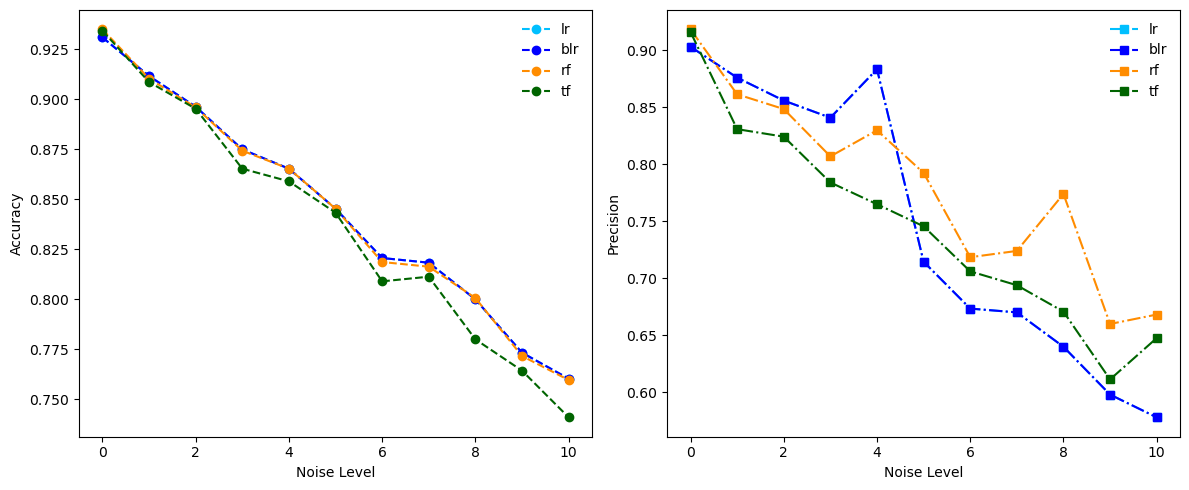

In [ ]:
colours2 = {'lr': 'deepskyblue', 'blr': 'blue', 'rf': 'darkorange', 'tf': 'darkgreen'}
mm = []

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Create two subplots
ax1, ax2 = axes  # Unpack the subplots

for i, kk in enumerate(cf_methods):
    x_acc = []
    x_prec = []
    if kk[1] == 'blr_mean':
        m_in = 'blr'
    else:
        m_in = kk[0]
    if m_in in mm:
        continue
    mm.append(m_in)
    for k in cf_results_dict:
        x_acc.append(model_results_dict[k][(kk[0], 'accuracy')])
        x_prec.append(model_results_dict[k][(kk[0], 'precision')])

    ax1.plot(x_acc, label=m_in, color=colours2[m_in], linestyle='--', marker='o')
    ax2.plot(x_prec, label=m_in, color=colours2[m_in], linestyle='-.', marker='s')

ax1.set_xlabel('Noise Level')
ax1.set_ylabel('Accuracy')
ax1.legend(frameon=False)
#ax1.set_title('Accuracy vs Noise Level')

ax2.set_xlabel('Noise Level')
ax2.set_ylabel('Precision')
ax2.legend(frameon=False)
#ax2.set_title('Precision vs Noise Level')

plt.tight_layout()
plt.savefig(f"plots/{dataset}_{variant}_accuracy_precision.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
def find_closest_noise(data, model, target=0.75):
    closest_noise = None
    min_diff = float("inf")  # Start with a very large difference

    for noise, metrics in data.items():
        if (model, "accuracy") in metrics:
            acc = metrics[(model, "accuracy")]
            diff = abs(acc - target)  # Compute absolute difference from 0.8
            
            if diff < min_diff:  # Update if this is the closest value so far
                min_diff = diff
                closest_noise = noise

    return closest_noise

# Example usage:
# closest_noise_for_lr = find_closest_noise(model_results_dict, 'rf')
# print("Closest noise level for 'lr':", closest_noise_for_lr)

In [2]:
iv

NameError: name 'iv' is not defined

Model: ('lr', 'skl')
/Users/leo/xai-cfs/data/mock_data1
2.020147766060321 1.2133879518533306 0.7575757575757576
/Users/leo/xai-cfs/data/mock_data2
1.7712226147455228 1.1215063576383553 0.7414141414141414
/Users/leo/xai-cfs/data/mock_data3
2.2383232503598793 1.2310794041095465 0.7626262626262627
/Users/leo/xai-cfs/data/mock_data4
1.4004560475575303 2.0349651957254933 0.7357575757575757
Model: ('lr', 'blr_mean')
/Users/leo/xai-cfs/data/mock_data1
1.9911883901105536 1.1983466327601626 0.7575757575757576
/Users/leo/xai-cfs/data/mock_data2
1.7712226147455228 1.1226724118081832 0.7414141414141414
/Users/leo/xai-cfs/data/mock_data3
2.233213685506675 1.2432962403300853 0.7626262626262627
/Users/leo/xai-cfs/data/mock_data4
1.4004560475575303 2.034976878975764 0.7357575757575757
Model: ('lr', 'nice')
/Users/leo/xai-cfs/data/mock_data1
2.0240871761062795 1.2186489973423777 0.7575757575757576
/Users/leo/xai-cfs/data/mock_data2
2.35449224730317 1.4961634256160277 0.7414141414141414
/Users/leo/xai-c

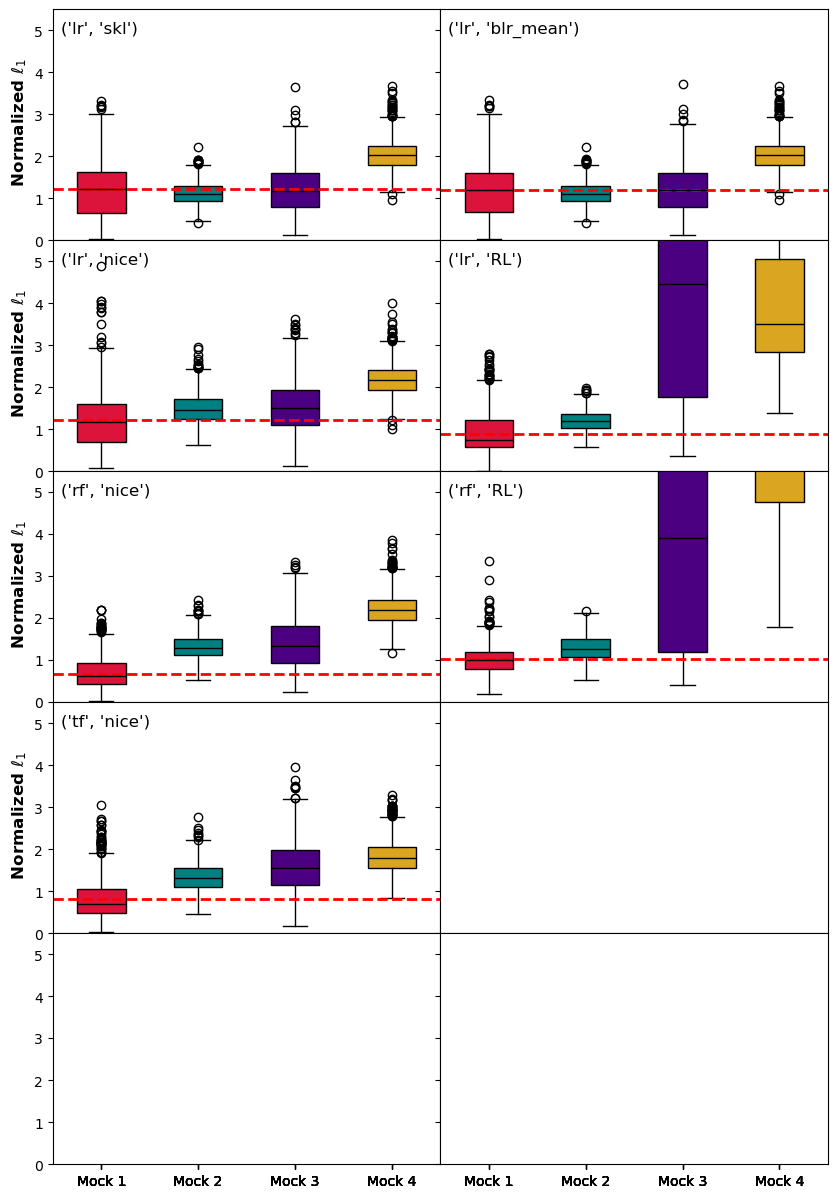

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(10, 15), sharex=True, sharey=True)
for idx, ml_cf in enumerate(l):
    row, col = divmod(idx, 2)  # Convert index to 5x2 grid positions
    ax = axes[row, col]
    print("Model:",ml_cf)
    ml_1 = []
    ml_2 = []
    for i in range(1,5):
        #for v in ["standard", "ommited_var_test", "noniid_test"]:
        #    if i!=3 and v in ["ommited_var_test", "noniid_test"]: continue
        v = "standard"
        data = load_dataset("mock_data"+str(i), variant=v,n_datasets=10)
        cf_results_dict = data["cf_results_dict"]
        cf_calc = data["cf_calc"]
        model_results_dict = data["model_results_dict"]
        cfs_good_indices = data["cfs_good_indices"]
        n_features = np.array(cf_results_dict['noise_0'][('lr','nice')]).shape[1]
        numerical_columns = [int(i) for i in cf_calc[0].num_cols_tf]
        categorical_columns = [int(i) for i in cf_calc[0].cat_cols_tf]

        noise_to_test = find_closest_noise(model_results_dict, ml_cf[0])

        A = cf_results_dict['noise_0'][ml_cf]
        B = cf_results_dict[noise_to_test][ml_cf]
        if ml_cf[1] in {'nice', 'dice', 'RL'} and ml_cf[0] != 'tf':
            A = cf_calc[4].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
            B = cf_calc[4].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)
        good_indices = cfs_good_indices[noise_to_test][ml_cf]
        m1 = get_distance(A[good_indices][:,-2:],B[good_indices][:,-2:], [0,1], [])
        m2 = get_distance(A[good_indices],B[good_indices],numerical_columns, categorical_columns, l_norm=l_order, n_features=n_features)
        ml_1.append(m1)
        ml_2.append(m2)
        print(np.mean(m1), np.mean(m2),model_results_dict[noise_to_test][(ml_cf[0], 'accuracy')])
    bplot = ax.boxplot(list(ml_2), tick_labels=['Mock 1', 'Mock 2', 'Mock 3', 'Mock 4'], widths=0.5, patch_artist=True)  # Plot boxplot for ml_1
    ax.set_ylim([0,5.5])
    if idx % n_cols == 0:
        #ax.set_ylabel(r'$\ell_1$', fontsize=12, fontweight='bold')
        ax.set_ylabel(r' Normalized $\ell_1$', fontsize=12, fontweight='bold')
    ax.text(0.02, 0.95, ml_cf, fontsize=12, verticalalignment='top', horizontalalignment='left', transform=ax.transAxes)
    ax.axhline(y=np.mean(ml_2[0]), color='red', linestyle='--', linewidth=2, label="Mean of Mock 1")
    for patch, color in zip(bplot['boxes'], ["crimson", "teal", "indigo", "goldenrod"]):
        patch.set_facecolor(color)
    for median in bplot['medians']:
        median.set_color('black')
    print("=====================================================")
fig.subplots_adjust(wspace=0, hspace=0)  # Set space between subplots to zero
#fig.savefig("plots/"+dataset+"_"+variant+"_.pdf", format="pdf", bbox_inches="tight")
#fig.supylabel(r' 2D $\ell_1$', fontsize=14)
#plt.tight_layout()

In [ ]:
l

[('lr', 'skl'),
 ('lr', 'blr_mean'),
 ('lr', 'nice'),
 ('lr', 'RL'),
 ('rf', 'nice'),
 ('rf', 'RL'),
 ('tf', 'nice')]

In [ ]:
l_minus_RL = [
    ('lr', 'skl'),
    ('lr', 'blr_mean'),
    ('lr', 'nice'),
    ('lr', 'dice'),
    ('rf', 'nice'),
    ('rf', 'dice'),
    ('tf', 'nice'),
    ('tf', 'dice')]

Model: ('lr', 'skl')
/Users/leo/xai-cfs/data/mock_data3
2.2383232503598793 1.2310794041095465 0.7626262626262627
/Users/leo/xai-cfs/data/mock_data3
1.6216308659345857 1.3029743956541082 0.7373737373737373
/Users/leo/xai-cfs/data/mock_data3
4.144341200871965 1.9904238589302972 0.7484848484848485
Model: ('lr', 'blr_mean')
/Users/leo/xai-cfs/data/mock_data3
2.233213685506675 1.2432962403300853 0.7626262626262627
/Users/leo/xai-cfs/data/mock_data3
1.626207565498357 1.3048251942386584 0.7373737373737373
/Users/leo/xai-cfs/data/mock_data3
3.9462689958463466 1.9635893040129788 0.7484848484848485
Model: ('lr', 'nice')
/Users/leo/xai-cfs/data/mock_data3
2.7377748322035544 1.534950877690819 0.7626262626262627
/Users/leo/xai-cfs/data/mock_data3
1.427347847975696 1.433924822054389 0.7373737373737373
/Users/leo/xai-cfs/data/mock_data3
3.347908270002863 1.8907911894515748 0.7484848484848485
Model: ('lr', 'dice')
/Users/leo/xai-cfs/data/mock_data3
2.665219556461086 1.5231916144265878 0.76262626262626

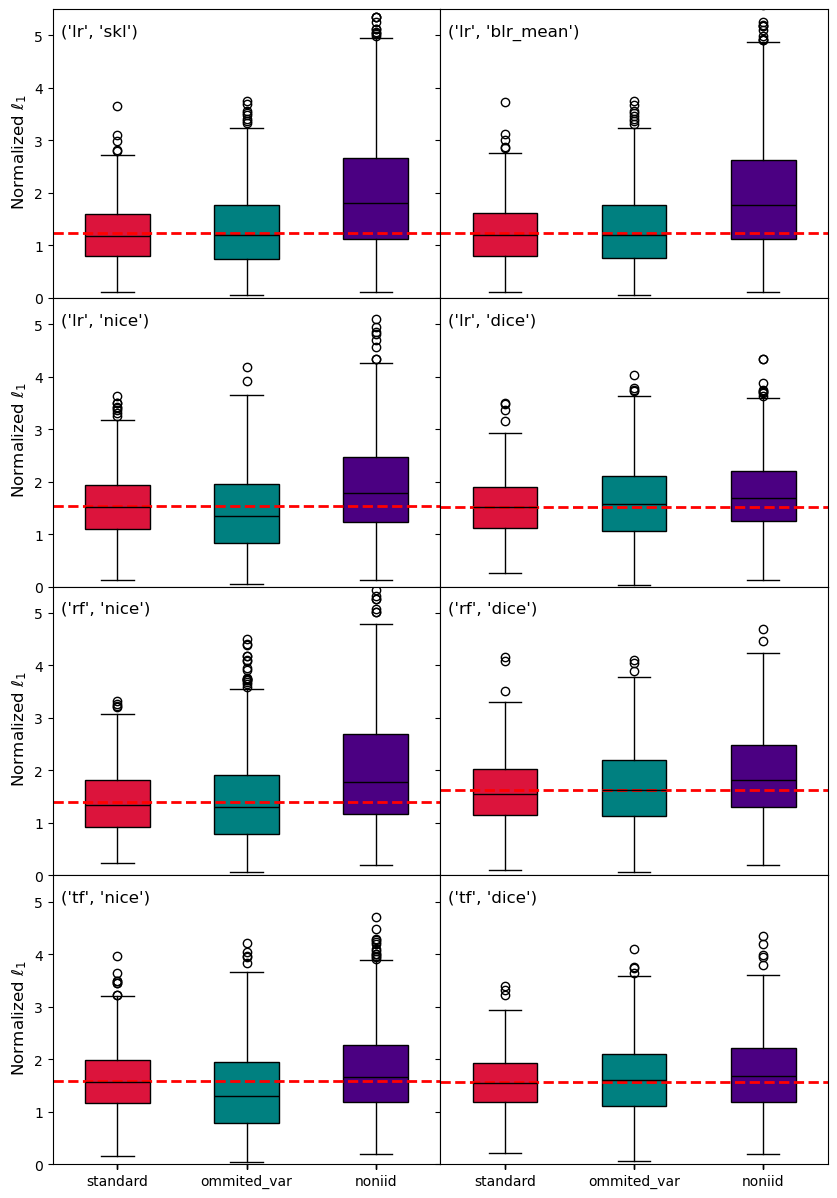

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(10, 15), sharex=True, sharey=True)
for idx, ml_cf in enumerate(l_minus_RL):
    #if ml_cf[1]=='RL': continue
    row, col = divmod(idx, 2)  # Convert index to 5x2 grid positions
    ax = axes[row, col]
    print("Model:",ml_cf)
    ml_1 = []
    ml_2 = []
    #for i in range(1,5):
    i = 3
    for v in ["standard", "ommited_var_test", "noniid_test"]:
        #if i!=3 and v in ["ommited_var_test", "noniid_test"]: continue
        #v = "standard"
        data = load_dataset("mock_data"+str(i), variant=v,n_datasets=10)
        cf_results_dict = data["cf_results_dict"]
        cf_calc = data["cf_calc"]
        model_results_dict = data["model_results_dict"]
        cfs_good_indices = data["cfs_good_indices"]
        n_features = np.array(cf_results_dict['noise_0'][('lr','nice')]).shape[1]
        numerical_columns = [int(i) for i in cf_calc[0].num_cols_tf]
        categorical_columns = [int(i) for i in cf_calc[0].cat_cols_tf]

        noise_to_test = find_closest_noise(model_results_dict, ml_cf[0])

        A = cf_results_dict['noise_0'][ml_cf]
        B = cf_results_dict[noise_to_test][ml_cf]
        if ml_cf[1] in {'nice', 'dice', 'RL'} and ml_cf[0] != 'tf':
            A = cf_calc[4].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
            B = cf_calc[4].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)
        good_indices = cfs_good_indices[noise_to_test][ml_cf]
        m1 = get_distance(A[good_indices][:,-2:],B[good_indices][:,-2:], [0,1], [])
        m2 = get_distance(A[good_indices],B[good_indices],numerical_columns, categorical_columns, l_norm=l_order, n_features=n_features)
        ml_1.append(m1)
        ml_2.append(m2)
        print(np.mean(m1), np.mean(m2),model_results_dict[noise_to_test][(ml_cf[0], 'accuracy')])
    if idx==6 | idx==7:
        bplot = ax.boxplot(list(ml_2), tick_labels=["standard", "ommited_var", "noniid"], widths=0.5, patch_artist=True)  # Plot boxplot for ml_1
    else:
        bplot = ax.boxplot(list(ml_2), tick_labels=["","",""], widths=0.5, patch_artist=True)  # Plot boxplot for ml_1
    ax.set_ylim([0,5.5])
    if idx % n_cols == 0:
        #ax.set_ylabel(r'$\ell_1$', fontsize=12, fontweight='bold')
        ax.set_ylabel(r' Normalized $\ell_1$', fontsize=12)
    ax.text(0.02, 0.95, ml_cf, fontsize=12, verticalalignment='top', horizontalalignment='left', transform=ax.transAxes)
    ax.axhline(y=np.mean(ml_2[0]), color='red', linestyle='--', linewidth=2, label="Mean of Mock 1")
    for patch, color in zip(bplot['boxes'], ["crimson", "teal", "indigo"]):
        patch.set_facecolor(color)
    for median in bplot['medians']:
        median.set_color('black')
    print("=====================================================")
fig.subplots_adjust(wspace=0, hspace=0)  # Set space between subplots to zero
fig.savefig("plots/epistemic_error1_.pdf", format="pdf", bbox_inches="tight")
#fig.supylabel(r' 2D $\ell_1$', fontsize=14)
#plt.tight_layout()